## Анализ результатов вычисления базисов Грёбнера

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette("tab10")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

Путь к файлу с результатами:

In [3]:
CSV_PATH = 'summary_table_for_analysis.csv'

Загрузка и предобработка данных:

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    'summary_table_for_analysis.csv',
    sep=';',                  # разделитель столбцов
    decimal=',',              # десятичный разделитель
    quotechar='"',            # кавычки вокруг строк
    skipinitialspace=True,    # убирает пробелы после запятых
    encoding='utf-8',
    low_memory=False
)

# Принудительно приводим числовые столбцы к float
numeric_cols = [
    'time', 'dimension', 'num_vars', 'num_equations', 'basis_size',
    'avr_memory', 'max_memory', 'mem_per_sec', 'crit1', 'crit2'
]

for col in numeric_cols:
    if col in df.columns:
        # Убираем возможные кавычки, пробелы и заменяем пустые строки на NaN
        df[col] = df[col].astype(str).str.strip().str.replace('"', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# В режиме clean обнуляем метрики памяти
if 'mode' in df.columns:
    clean_mask = df['mode'] == 'clean'
    for col in ['avr_memory', 'max_memory', 'mem_per_sec']:
        if col in df.columns:
            df.loc[clean_mask, col] = np.nan

df['completed'] = df['status'] == 'ok'
df['timed_out'] = df['status'] == 'timeout'
df['has_error'] = df['status'] == 'error'

In [5]:
df.head(10)

,test,method,order,time,dimension,num_vars,num_equations,basis_size,avr_memory,max_memory,mem_per_sec,crit1,crit2,mode,status,completed,timed_out,has_error
0,assur44,ginv,deglex,600.039,8,8,8,NaN,NaN,NaN,NaN,NaN,NaN,clean,timeout,False,True,False
1,assur44,sympy,deglex,600.030,8,8,8,NaN,NaN,NaN,NaN,NaN,NaN,clean,timeout,False,True,False
2,boon,ginv,deglex,0.143,6,6,0,12.0,NaN,NaN,NaN,108.0,32.0,clean,ok,True,False,False
3,boon,sympy,deglex,0.035,6,6,6,11.0,NaN,NaN,NaN,NaN,NaN,clean,ok,True,False,False
4,butcher8,ginv,deglex,44.038,8,8,0,54.0,NaN,NaN,NaN,568.0,1292.0,clean,ok,True,False,False
5,butcher8,sympy,deglex,29.880,8,8,8,54.0,NaN,NaN,NaN,NaN,NaN,clean,ok,True,False,False
6,butcher,ginv,deglex,9.838,7,7,0,27.0,NaN,NaN,NaN,192.0,360.0,clean,ok,True,False,False
7,butcher,sympy,deglex,0.570,7,7,7,26.0,NaN,NaN,NaN,NaN,NaN,clean,ok,True,False,False
8,camera1s,ginv,deglex,2.840,6,6,0,26.0,NaN,NaN,NaN,177.0,82.0,clean,ok,True,False,False
9,camera1s,sympy,deglex,2.217,6,6,6,31.0,NaN,NaN,NaN,NaN,NaN,clean,ok,True,False,False


### Сравнение среднего времени

In [6]:
print("="*60)
print("Сравнение среднего времени (с учётом таймаутов)")
print("="*60)

stats = df.groupby('method')['time'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(3)
print(stats)

# Кто в среднем быстрее
mean_sympy = stats.loc['sympy', 'mean']
mean_ginv = stats.loc['ginv', 'mean']
print(f"\nВ среднем быстрее: {'SymPy' if mean_sympy < mean_ginv else 'GInv'} "
      f"({min(mean_sympy, mean_ginv):.2f} сек < {max(mean_sympy, mean_ginv):.2f} сек)")

Сравнение среднего времени (с учётом таймаутов)
        count    mean  median      std    min      max
method                                                
ginv       45  56.115   2.141  146.613  0.003  600.039
sympy      45  88.857   0.848  193.534  0.003  600.030

В среднем быстрее: GInv (56.12 сек < 88.86 сек)


### Сравнение по тестам

In [7]:
pivot = df.pivot_table(index='test', columns='method', values=['time', 'status'], aggfunc='first')

# Упрощаем
pivot_time = pivot['time'].copy()
pivot_time['winner'] = pivot_time.apply(
    lambda row: 'SymPy' if row['sympy'] < row.get('ginv', np.inf) else
                'GInv' if row['ginv'] < row.get('sympy', np.inf) else
                'Оба таймаут' if pd.isna(row['sympy']) and pd.isna(row['ginv']) else 'Ничья', axis=1)

print("Количество наиболее быстрых расчетов по тестам")
pivot_time['winner'].value_counts()

Количество наиболее быстрых расчетов по тестам


winner
SymPy    33
GInv     11
Ничья     1
Name: count, dtype: int64

#### Сравнительный анализ GInv и SymPy

In [8]:
print("="*60)
print("Tесты, где GInv значительно быстрее:")
print("="*60)
print(pivot_time[pivot_time['winner'] == 'GInv'].sort_values('ginv').head(10))

print("="*60)
print("Тесты, где SymPy значительно быстрее:")
print("="*60)
print(pivot_time[pivot_time['winner'] == 'SymPy'].sort_values('sympy').head(10))

Tесты, где GInv значительно быстрее:
method       ginv    sympy winner
test                             
sparse5     0.003    0.005   GInv
hunecke     0.011   19.397   GInv
liu         0.074   17.534   GInv
chemequs    2.141   10.675   GInv
tangents    3.388   17.364   GInv
cassou      3.671  600.021   GInv
redcyc6    24.425  600.025   GInv
hcyclic6   26.570  225.783   GInv
cyclic6    96.247  355.852   GInv
cpdm5     104.883  116.795   GInv
Тесты, где SymPy значительно быстрее:
method      ginv  sympy winner
test                          
solotarev  0.017  0.007  SymPy
chandra4   0.049  0.010  SymPy
hemmecke   0.090  0.015  SymPy
lorentz    0.054  0.016  SymPy
quadgrid   0.055  0.020  SymPy
boon       0.143  0.035  SymPy
chandra5   0.233  0.053  SymPy
caprasse   0.247  0.102  SymPy
redcyc5    0.561  0.109  SymPy
issac97    0.279  0.134  SymPy


## Таймаут по тестам

Тесты, где один завершился, а другой нет

In [9]:
diff_status = df.pivot_table(index='test', columns='method', values='status', aggfunc='first')
print(diff_status[diff_status.nunique(axis=1) > 1])

method  ginv    sympy
test                 
cassou    ok  timeout
extcyc5   ok  timeout
redcyc6   ok  timeout


## Визуализация

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8144\841910436.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


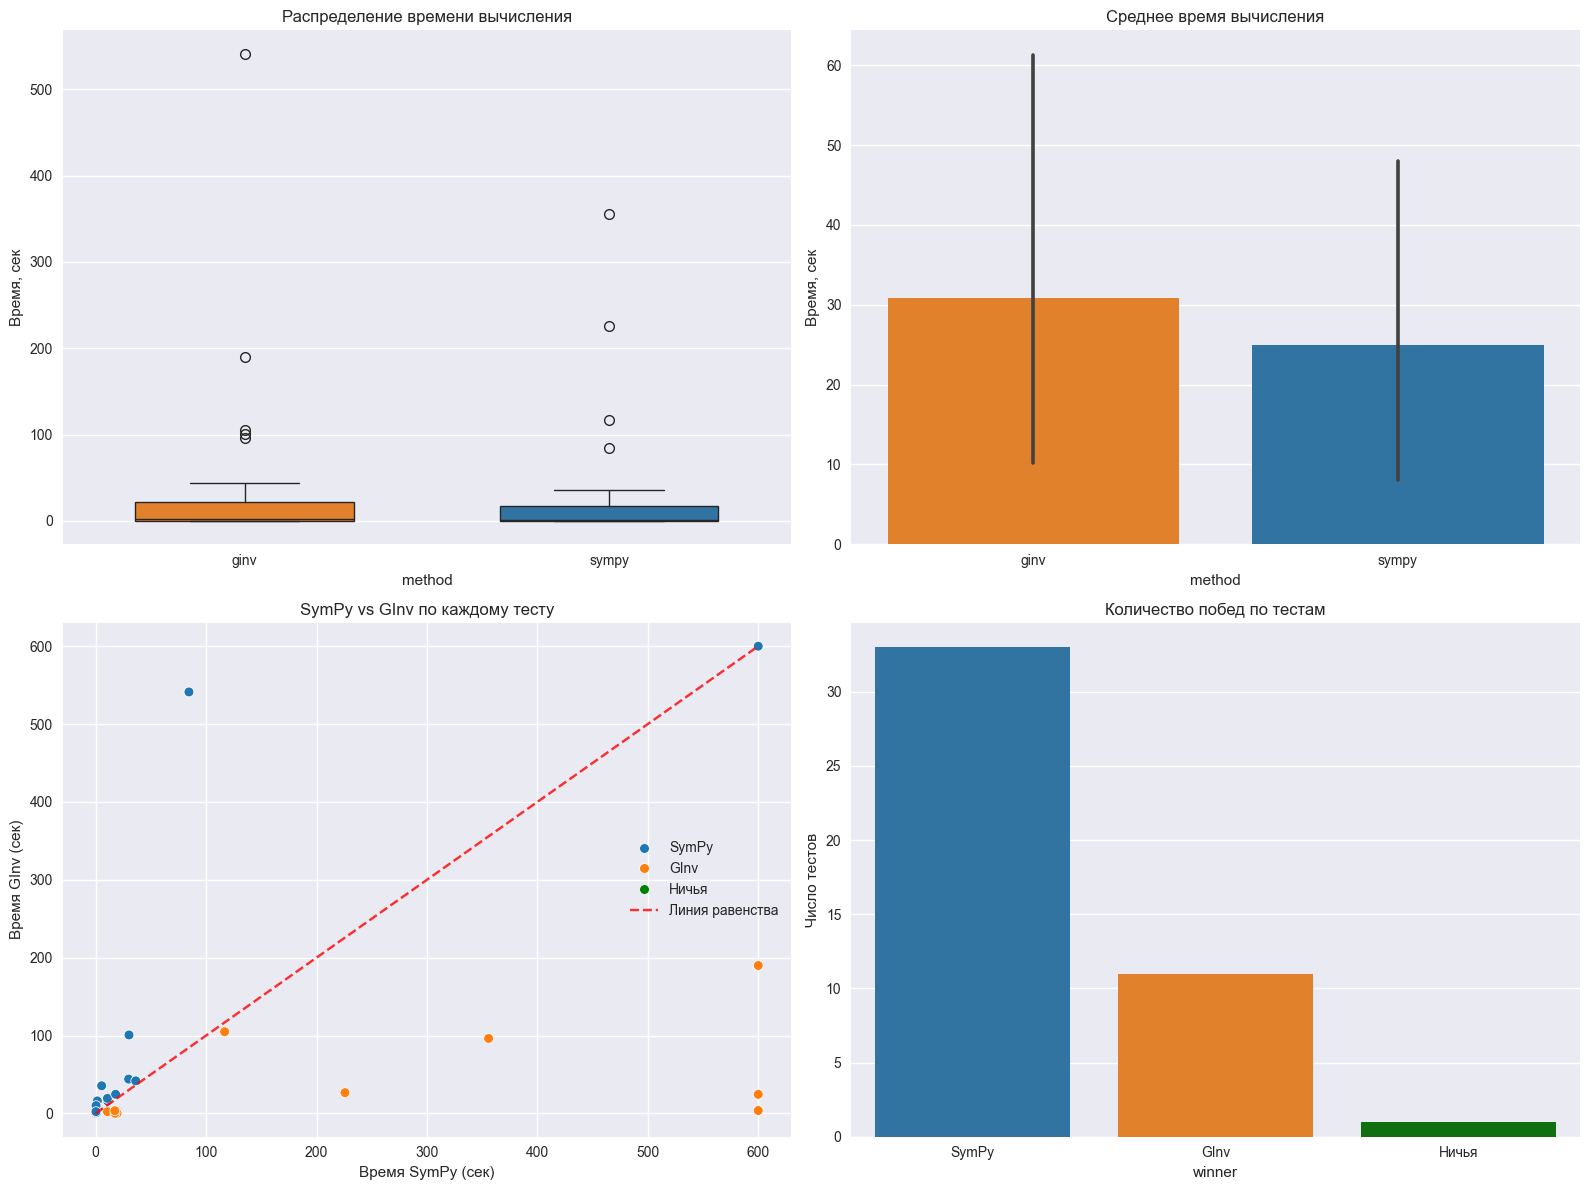

In [11]:
fig = plt.figure(figsize=(16, 12))

method_colors = {
    'sympy': '#1f77b4',
    'ginv':  '#ff7f0e',
    'SymPy': '#1f77b4',
    'GInv':  '#ff7f0e',
    'Ничья': 'green'

}

df_ok = df[df['status'] == 'ok'].copy()

# 1. Boxplot
ax1 = fig.add_subplot(2, 2, 1)
sns.boxplot(
    data=df_ok,
    x='method',
    y='time',
    ax=ax1,
    hue='method',
    palette=method_colors,
    showfliers=True,
    width=0.6,
    dodge=False
)
ax1.set_title('Распределение времени вычисления')
ax1.set_ylabel('Время, сек')

# 2. Barplot среднего
ax2 = fig.add_subplot(2, 2, 2)
sns.barplot(
    data=df_ok,
    x='method',
    y='time',
    ax=ax2,
    hue='method',
    palette=method_colors,
    estimator='mean'
)
ax2.set_title('Среднее время вычисления')
ax2.set_ylabel('Время, сек')

# 3. Scatter (по winner)
ax3 = fig.add_subplot(2, 2, 3)
sns.scatterplot(
    data=pivot_time,
    x='sympy',
    y='ginv',
    hue='winner',
    palette=method_colors,
    s=50,
    ax=ax3
)
ax3.plot([0, pivot_time[['sympy','ginv']].max().max()],
         [0, pivot_time[['sympy','ginv']].max().max()],
         'r--', alpha=0.8, label='Линия равенства')
ax3.set_xlabel('Время SymPy (сек)')
ax3.set_ylabel('Время GInv (сек)')
ax3.set_title('SymPy vs GInv по каждому тесту')
ax3.legend()

# 4. Countplot побед
ax4 = fig.add_subplot(2, 2, 4)
sns.countplot(
    data=pivot_time,
    x='winner',
    ax=ax4,
    palette=method_colors
)
ax4.set_title('Количество побед по тестам')
ax4.set_ylabel('Число тестов')

plt.tight_layout()
plt.show()

### Сравнение времени по всем тестам

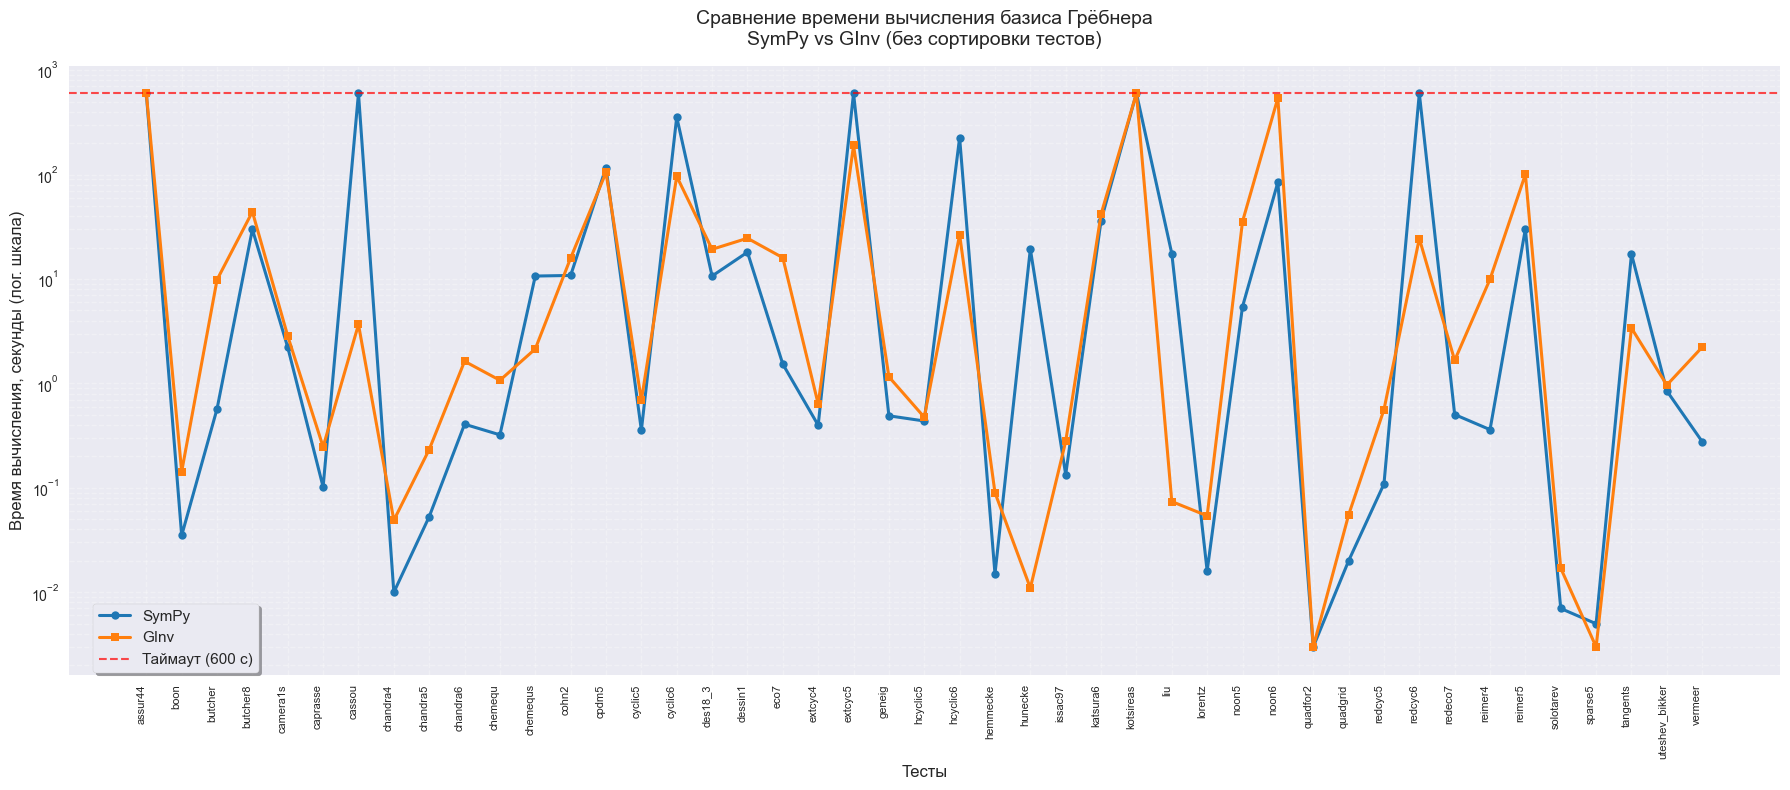

In [12]:
plt.figure(figsize=(18, 8))

pivot_time = df.pivot_table(
    index='test',
    columns='method',
    values='time',
    aggfunc='first'
).reset_index()

# Линия SymPy
plt.plot(pivot_time.index, pivot_time['sympy'], 
         marker='o', markersize=6, linewidth=2.2, 
         label='SymPy', color='#1f77b4')

# Линия GInv
plt.plot(pivot_time.index, pivot_time['ginv'], 
         marker='s', markersize=6, linewidth=2.2, 
         label='GInv', color='#ff7f0e')

# Линия таймаута
if df['timed_out'].any():
    timeout_value = df[df['timed_out']]['time'].max()
    plt.axhline(y=timeout_value, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Таймаут ({timeout_value:.0f} с)')

# Вертикальные подписи тестов
plt.xticks(ticks=pivot_time.index, 
           labels=pivot_time['test'], 
           rotation=90, 
           ha='right', 
           fontsize=8)

# Настройки осей и легенды
plt.yscale('log')  # логарифмическая шкала для наглядности
plt.ylabel('Время вычисления, секунды (лог. шкала)', fontsize=12)
plt.xlabel('Тесты', fontsize=12)
plt.title('Сравнение времени вычисления базиса Грёбнера\nSymPy vs GInv (без сортировки тестов)', fontsize=14, pad=15)

plt.grid(True, which="both", ls="--", alpha=0.3)

plt.legend(loc='lower left', fontsize=11, frameon=True, shadow=True, bbox_to_anchor=(0.01, -0.01))
plt.tight_layout()
plt.show()

In [13]:
# Таблица разницы (топ-10 самых больших расхождений)
pivot_time['diff_sec'] = pivot_time['ginv'] - pivot_time['sympy']
pivot_time['ratio'] = (pivot_time['ginv'] / pivot_time['sympy']).round(2)

print("\nТоп-10 тестов, где GInv медленнее SymPy (по разнице в секундах):")
print(pivot_time.sort_values('diff_sec', ascending=False).head(10)[
    ['test', 'sympy', 'ginv', 'diff_sec', 'ratio']
])

print("\nТоп-10 тестов, где GInv быстрее SymPy:")
print(pivot_time.sort_values('diff_sec').head(10)[
    ['test', 'sympy', 'ginv', 'diff_sec', 'ratio']
])


Топ-10 тестов, где GInv медленнее SymPy (по разнице в секундах):
method      test   sympy     ginv  diff_sec  ratio
32         noon6  84.481  541.257   456.776   6.41
39       reimer5  30.196  100.696    70.500   3.33
31         noon5   5.434   35.438    30.004   6.52
18          eco7   1.531   15.997    14.466  10.45
3       butcher8  29.880   44.038    14.158   1.47
38       reimer4   0.361    9.964     9.603  27.60
2        butcher   0.570    9.838     9.268  17.26
16       des18_3  10.679   19.252     8.573   1.80
17       dessin1  18.068   24.569     6.501   1.36
27      katsura6  36.270   41.768     5.498   1.15

Топ-10 тестов, где GInv быстрее SymPy:
method      test    sympy     ginv  diff_sec  ratio
6         cassou  600.021    3.671  -596.350   0.01
36       redcyc6  600.025   24.425  -575.600   0.04
20       extcyc5  600.016  189.905  -410.111   0.32
15       cyclic6  355.852   96.247  -259.605   0.27
23      hcyclic6  225.783   26.570  -199.213   0.12
25       hunecke   19

### Сравнение времени по всем тестам (с сортировкой по времени)

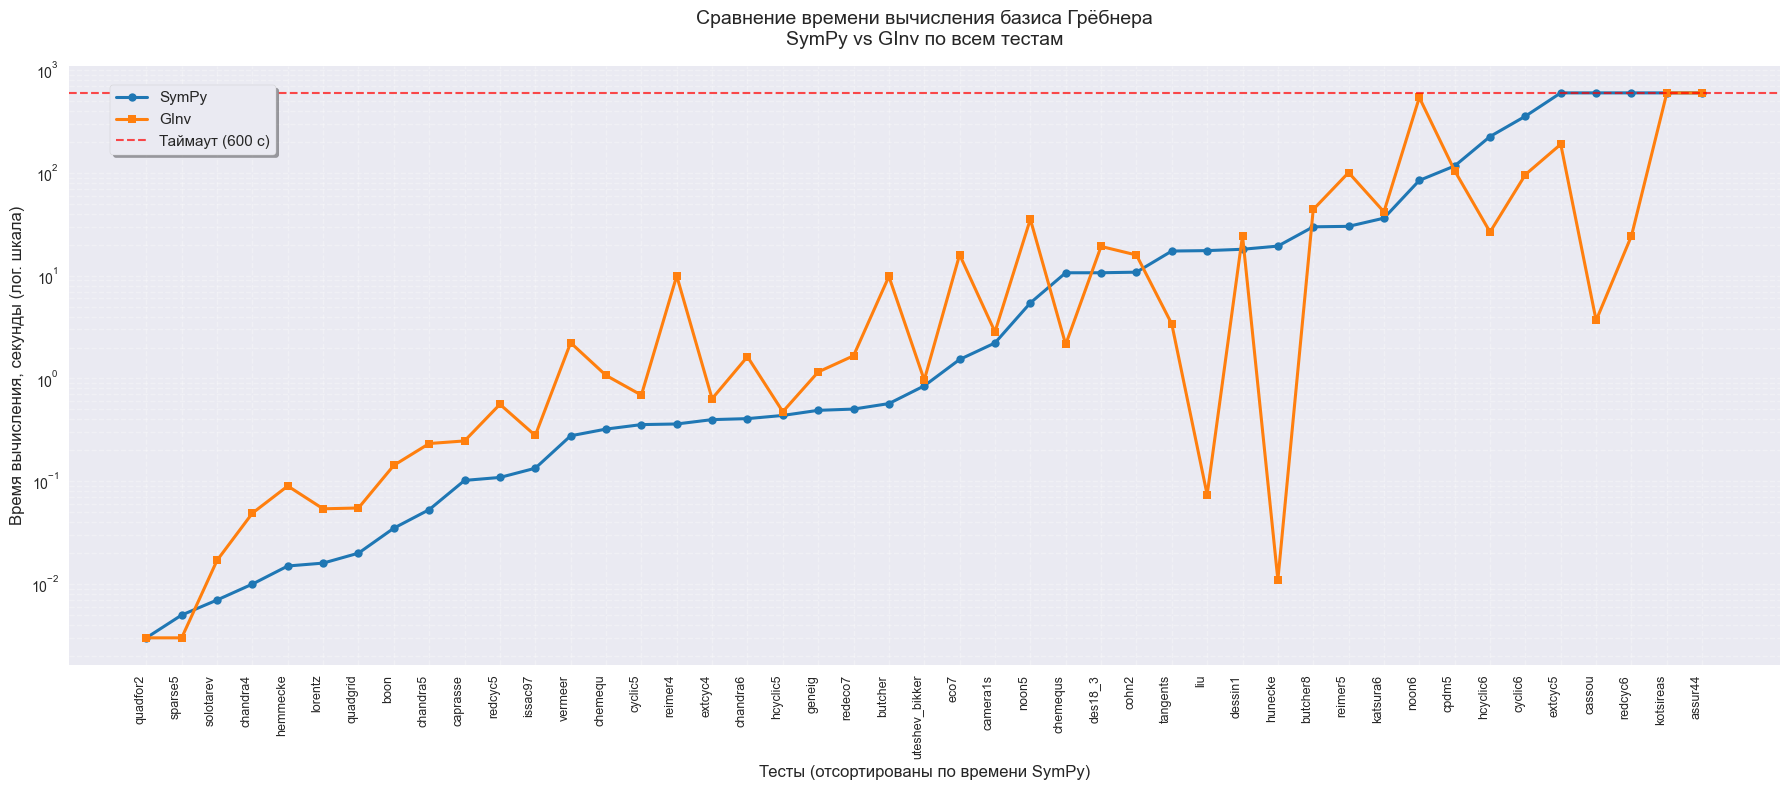

In [14]:
# Сортируем тесты по времени SymPy (от самого быстрого к медленному)
pivot_time = pivot_time.sort_values('sympy', ascending=True).reset_index(drop=True)

plt.figure(figsize=(18, 8))

# Линия SymPy
plt.plot(pivot_time.index, pivot_time['sympy'], 
         marker='o', markersize=6, linewidth=2.2, 
         label='SymPy', color='#1f77b4')

# Линия GInv
plt.plot(pivot_time.index, pivot_time['ginv'], 
         marker='s', markersize=6, linewidth=2.2, 
         label='GInv', color='#ff7f0e')

# Линия таймаута
if df['timed_out'].any():
    timeout_value = df[df['timed_out']]['time'].max()  # берём максимальное значение таймаута
    plt.axhline(y=timeout_value, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Таймаут ({timeout_value:.0f} с)')

# Вертикальные подписи тестов
plt.xticks(ticks=pivot_time.index, 
           labels=pivot_time['test'], 
           rotation=90, 
           ha='right', 
           fontsize=9, 
           fontfamily='Arial')

# Настройки осей
plt.yscale('log')  # логарифмическая шкала
plt.ylabel('Время вычисления, секунды (лог. шкала)', fontsize=12)
plt.xlabel('Тесты (отсортированы по времени SymPy)', fontsize=12)
plt.title('Сравнение времени вычисления базиса Грёбнера\nSymPy vs GInv по всем тестам', 
          fontsize=14, pad=15)

plt.grid(True, which="both", ls="--", alpha=0.3)

# Легенда
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True, bbox_to_anchor=(0.02, 0.98))
plt.tight_layout()
plt.show()

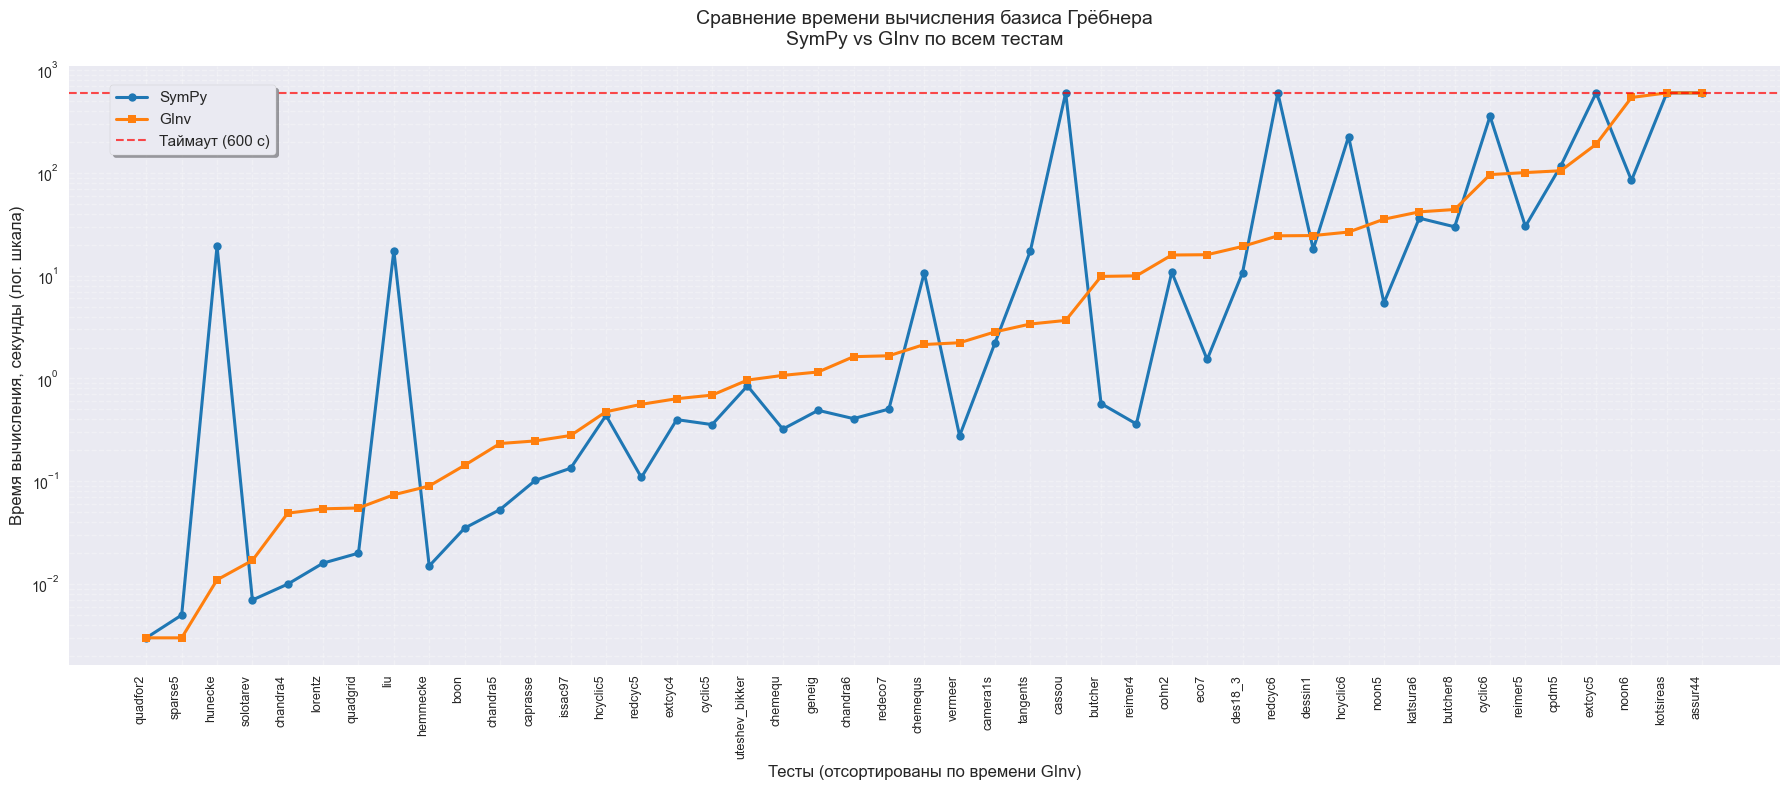

In [15]:
# Сортируем тесты по времени GInv (от самого быстрого к медленному)
pivot_time = pivot_time.sort_values('ginv', ascending=True).reset_index(drop=True)

plt.figure(figsize=(18, 8))

# Линия SymPy
plt.plot(pivot_time.index, pivot_time['sympy'], 
         marker='o', markersize=6, linewidth=2.2, 
         label='SymPy', color='#1f77b4')

# Линия GInv
plt.plot(pivot_time.index, pivot_time['ginv'], 
         marker='s', markersize=6, linewidth=2.2, 
         label='GInv', color='#ff7f0e')

# Линия таймаута
if df['timed_out'].any():
    timeout_value = df[df['timed_out']]['time'].max()  # берём максимальное значение таймаута
    plt.axhline(y=timeout_value, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Таймаут ({timeout_value:.0f} с)')

# Вертикальные подписи тестов
plt.xticks(ticks=pivot_time.index, 
           labels=pivot_time['test'], 
           rotation=90, 
           ha='right', 
           fontsize=9, 
           fontfamily='Arial')

# Настройки осей
plt.yscale('log')  # логарифмическая шкала
plt.ylabel('Время вычисления, секунды (лог. шкала)', fontsize=12)
plt.xlabel('Тесты (отсортированы по времени GInv)', fontsize=12)
plt.title('Сравнение времени вычисления базиса Грёбнера\nSymPy vs GInv по всем тестам', 
          fontsize=14, pad=15)

plt.grid(True, which="both", ls="--", alpha=0.3)

# Легенда
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True, bbox_to_anchor=(0.02, 0.98))
plt.tight_layout()
plt.show()